# Clinical statistics and figure assembly

`omicverse` is strong on omics-specific figures — embeddings, spatial maps,
cell-cell communication — but a paper needs more than those. A cohort needs a
survival curve, a classifier needs an ROC, a set of effect sizes needs a forest
plot, and all of it has to end up as one correctly sized panel figure whose
text is still editable in Illustrator.

This tutorial covers the part of `ov.pl` that does that:

| Function | What it draws |
| --- | --- |
| `ov.pl.survival` | Kaplan-Meier curves, confidence band, numbers at risk, log-rank test, hazard ratio |
| `ov.pl.cumulative_incidence` | Aalen-Johansen incidence under competing risks, Gray's test |
| `ov.pl.roc` | ROC curves with DeLong confidence intervals, multi-model and multi-class |
| `ov.pl.confusion` | Confusion matrix with accuracy / balanced accuracy / kappa / per-class F1 |
| `ov.pl.forest` | Effect sizes with CIs, subgroups, fixed/random-effects meta-analysis |
| `ov.pl.figure` | A canvas sized in mm / cm / inches / pixels, or by journal column preset |
| `ov.pl.multipanel` | A labelled panel grid or mosaic |
| `ov.pl.add_panel_label` | The `a` / `b` / `c` tags, offset in typographic points |
| `ov.pl.savefig` | Export to several formats at once, keeping text as text |
| `ov.pl.take_legend_out` | Move a legend outside the axes |

Two things are worth saying up front.

**None of these needs an `AnnData`.** They take a `pandas.DataFrame` and column
names, or bare NumPy arrays, or an `AnnData` (in which case `.obs` is used).
The last section shows all three forms giving the same answer.

**The statistics are real.** The estimators are implemented on NumPy/SciPy and
pinned in the test suite against `lifelines` (Kaplan-Meier, log-rank,
Aalen-Johansen), R `pROC` (DeLong intervals), R `cmprsk` (Gray's test) and
`statsmodels` (meta-analysis).

In [1]:
import logging
import os
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("fontTools").setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov

os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)
ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. The cohort

We use the **TCGA Pan-Cancer Clinical Data Resource** (Liu et al., *Cell* 2018,
"An Integrated TCGA Pan-Cancer Clinical Data Resource to Drive High-Quality
Survival Outcome Analytics"), served as a plain table by UCSC Xena. It covers
12,591 samples across 33 cancer types and — importantly for the competing-risk
section — records both overall survival (`OS`) and disease-specific survival
(`DSS`), so we can tell a cancer death from a death of another cause.

In [2]:
url = ("https://pancanatlas.xenahubs.net/download/"
       "Survival_SupplementalTable_S1_20171025_xena_sp")
path = "data/tcga_pancancer_clinical.tsv"
if not os.path.exists(path):
    pd.read_csv(url, sep="\t").to_csv(path, sep="\t", index=False)
clin = pd.read_csv(path, sep="\t")
clin.shape

(12591, 34)

In [3]:
clin[["cancer type abbreviation", "age_at_initial_pathologic_diagnosis",
      "ajcc_pathologic_tumor_stage", "OS", "OS.time", "DSS"]].head()

,cancer type abbreviation,age_at_initial_pathologic_diagnosis,ajcc_pathologic_tumor_stage,OS,OS.time,DSS
0,ACC,58.0,Stage II,1.0,1355.0,1.0
1,ACC,44.0,Stage IV,1.0,1677.0,1.0
2,ACC,23.0,Stage III,0.0,2091.0,0.0
3,ACC,23.0,Stage IV,1.0,423.0,1.0
4,ACC,30.0,Stage III,1.0,365.0,1.0


A little tidying: overall survival in months, and the AJCC pathologic
stage collapsed into early (I-II) versus advanced (III-IV). Stage strings in
TCGA are messy (`Stage IIIA`, `Stage IIB`, `[Discrepancy]`, ...), so we map on
the Roman numeral.

In [4]:
def stage_group(value):
    text = str(value)
    if "IV" in text or "III" in text:
        return "Stage III-IV"
    if "II" in text or "I" in text:
        return "Stage I-II"
    return None

clin["months"] = clin["OS.time"] / 30.44
clin["stage"] = clin["ajcc_pathologic_tumor_stage"].map(stage_group)
clin["stage"] = pd.Categorical(clin["stage"], ["Stage I-II", "Stage III-IV"])

In [5]:
cohort = clin.dropna(subset=["months", "OS", "stage"])
cohort = cohort[cohort["months"] > 0]
kirc = cohort[cohort["cancer type abbreviation"] == "KIRC"]
print(f"{len(cohort)} patients across {cohort['cancer type abbreviation'].nunique()} cancer types")
kirc["stage"].value_counts()

8051 patients across 21 cancer types


stage
Stage I-II      550
Stage III-IV    388
Name: count, dtype: int64

## 2. Kaplan-Meier curves — `ov.pl.survival`

Clear-cell renal carcinoma (KIRC) is a good first example: stage is strongly
prognostic and the cohort is large enough for a stable curve.

The default draws everything a reviewer will ask for — the log-log confidence
band, censoring ticks, the numbers-at-risk table, the log-rank P value and the
hazard ratio. The time axis is handed down to the risk table, which is where
journals put it.

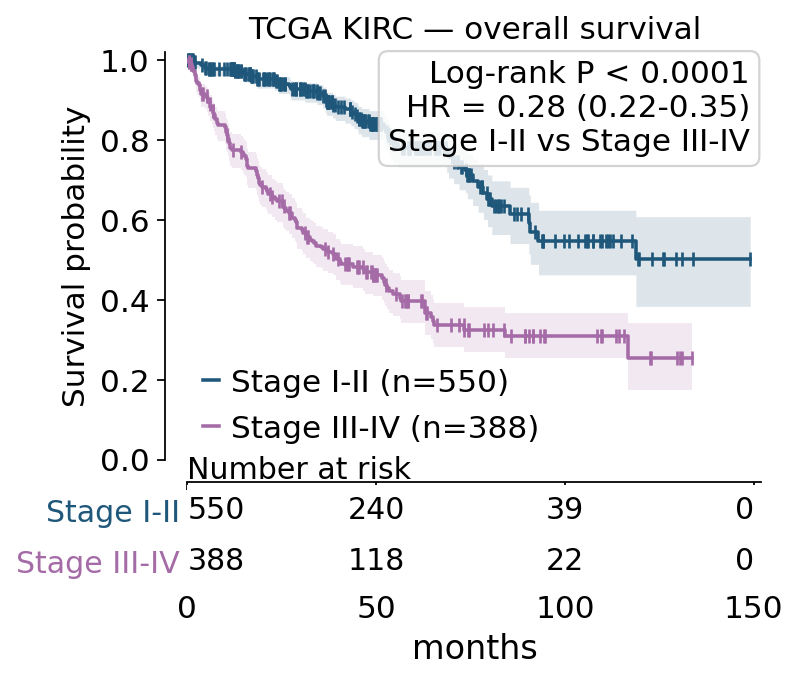

In [6]:
ax = ov.pl.survival(kirc, time="months", event="OS", group="stage",
                    figsize=(4.6, 4.4), title="TCGA KIRC — overall survival")
plt.show()

Everything the plot annotates is also returned, so the numbers can go
into the text of a paper rather than being read off a figure.

In [7]:
ax, stats = ov.pl.survival(kirc, "months", "OS", "stage",
                           figsize=(4.6, 4.4), return_stats=True)
plt.close()
lo, hi = stats["hazard_ratio_ci"]
print(f"log-rank chi2 = {stats['statistic']:.1f}, P = {stats['pvalue']:.2e}")
print(f"HR = {stats['hazard_ratio']:.2f} ({lo:.2f}-{hi:.2f}), "
      f"{stats['groups'][0]} vs {stats['hazard_ratio_reference']}")

log-rank chi2 = 140.0, P = 2.64e-32
HR = 0.28 (0.22-0.35), Stage I-II vs Stage III-IV


In [8]:
def fmt(value):
    return "not reached" if not np.isfinite(value) else f"{value:.1f}"

for level, fit in stats["fits"].items():
    lo, hi = fit["median_ci"]
    print(f"{level:<14} n={fit['n']:>4}  events={fit['n_events']:>4}  "
          f"median = {fmt(fit['median'])} months (95% CI {fmt(lo)}-{fmt(hi)})")

Stage I-II     n= 550  events= 112  median = not reached months (95% CI 90.8-not reached)
Stage III-IV   n= 388  events= 226  median = 40.4 months (95% CI 32.6-52.2)


The reference group is the **first** level — taken from the `Categorical`
category order if the column has one, and otherwise from sorting the labels.
It never depends on which patient happens to be first in the file. Pass
`groups=` to choose it explicitly and flip the direction of the hazard ratio.

In [9]:
flipped = ov.pl.logrank_test(kirc["months"], kirc["OS"], kirc["stage"],
                             groups=["Stage III-IV", "Stage I-II"])
lo, hi = flipped["hazard_ratio_ci"]
print(f"HR = {flipped['hazard_ratio']:.2f} ({lo:.2f}-{hi:.2f}), "
      f"advanced vs early  —  the same chi2 = {flipped['statistic']:.1f}")

HR = 3.58 (2.87-4.47), advanced vs early  —  the same chi2 = 140.0


The same call works without any table at all — pass arrays. This is the
point of the whole group: nothing here is tied to a container.

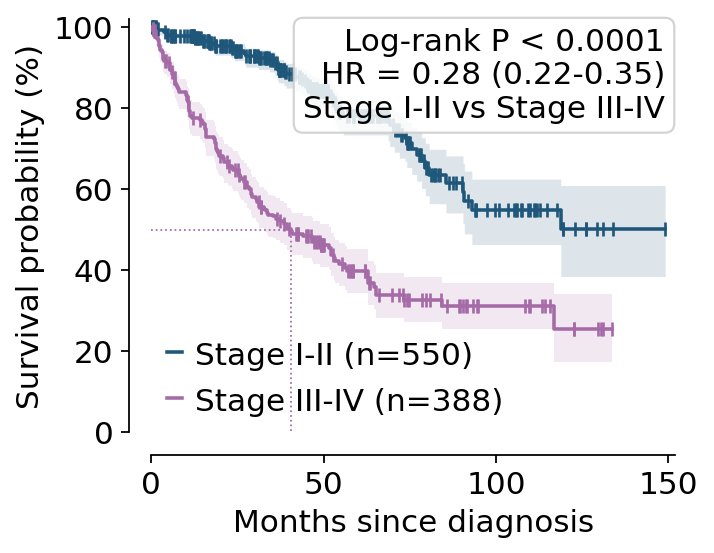

In [10]:
ax = ov.pl.survival(time=kirc["months"].to_numpy(),
                    event=kirc["OS"].to_numpy(),
                    group=kirc["stage"].astype(str).to_numpy(),
                    figsize=(4.2, 3.4), risk_table=False, percent=True,
                    median_line=True, xlabel="Months since diagnosis")
plt.show()

## 3. Competing risks — `ov.pl.cumulative_incidence`

Older TCGA patients die of things other than their tumour. If we ask "what
fraction relapse-free died *of cancer* by five years?" and answer it with
`1 - KM`, treating a death from another cause as censoring, the answer is too
high — censoring assumes the patient could still have had the event, and a dead
patient cannot.

`DSS` marks disease-specific death, so we can build a proper competing-risk
coding: `1` = death from the cancer, `2` = death from another cause, `0` =
alive at last contact.

In [11]:
both = cohort.dropna(subset=["DSS"]).copy()
both["cause"] = np.where(both["OS"] == 0, 0, np.where(both["DSS"] == 1, 1, 2))
lihc = both[both["cancer type abbreviation"] == "LIHC"]
pd.Series(lihc["cause"]).map({0: "censored", 1: "cancer death",
                              2: "other-cause death"}).value_counts()

cause
censored             249
cancer death          80
other-cause death     56
Name: count, dtype: int64

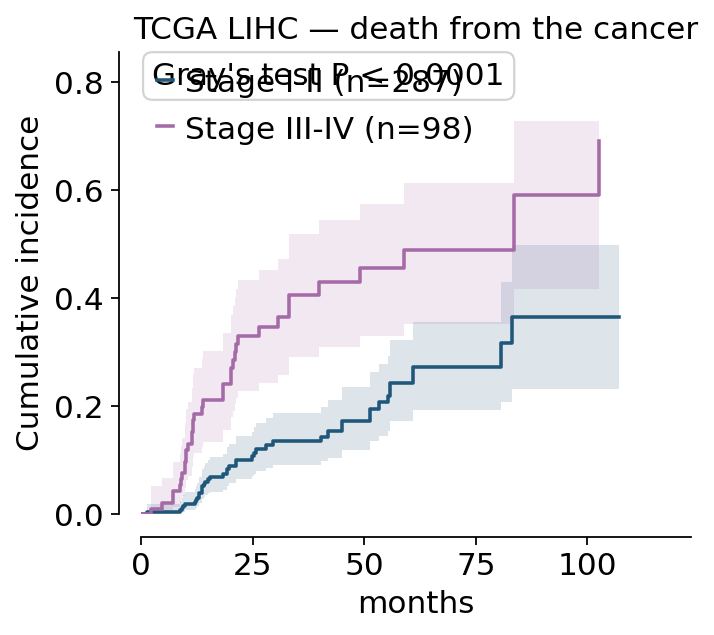

In [12]:
ax = ov.pl.cumulative_incidence(lihc, "months", "cause", "stage", cause=1,
                                figsize=(4.4, 3.8), ci=True,
                                title="TCGA LIHC — death from the cancer")
plt.show()

`show_naive_km=True` overlays the `1 - KM` curve that ignores the
competing risk, as a dashed line. It is always at or above the correct curve;
the gap is the size of the mistake.

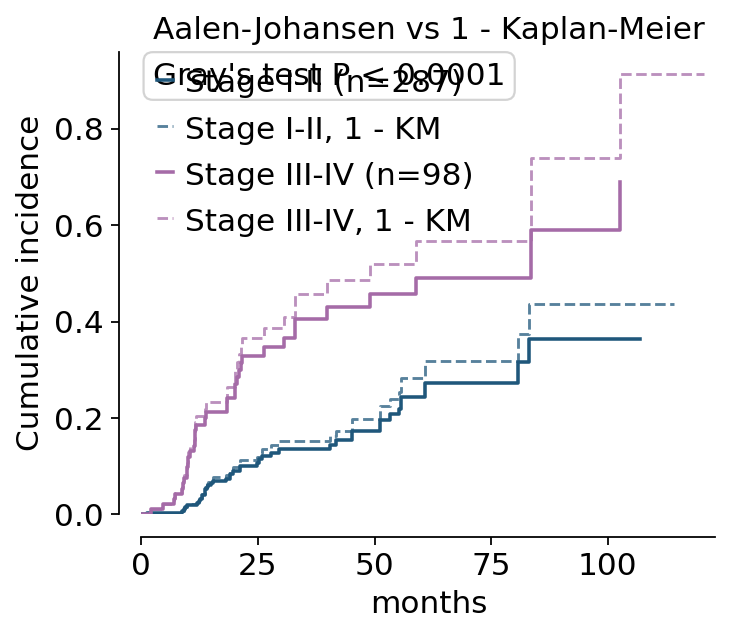

In [13]:
ax = ov.pl.cumulative_incidence(lihc, "months", "cause", "stage", cause=1,
                                figsize=(4.6, 3.8), show_naive_km=True,
                                title="Aalen-Johansen vs 1 - Kaplan-Meier")
plt.show()

In [14]:
fit = ov.pl.aalen_johansen(lihc["months"], lihc["cause"], cause=1)
km = ov.pl.kaplan_meier(lihc["months"], lihc["cause"] == 1)
at = lambda t, v, q: v[np.searchsorted(t, q, side="right") - 1]
print(f"5-year cancer death, Aalen-Johansen : {at(fit['timeline'], fit['cif'], 60):.3f}")
print(f"5-year cancer death, 1 - KM         : {1 - at(km['timeline'], km['survival'], 60):.3f}")

5-year cancer death, Aalen-Johansen : 0.311
5-year cancer death, 1 - KM         : 0.360


Both causes can be shown together for one cohort, which makes the
partition explicit: the two curves plus the survivors add up to 1.

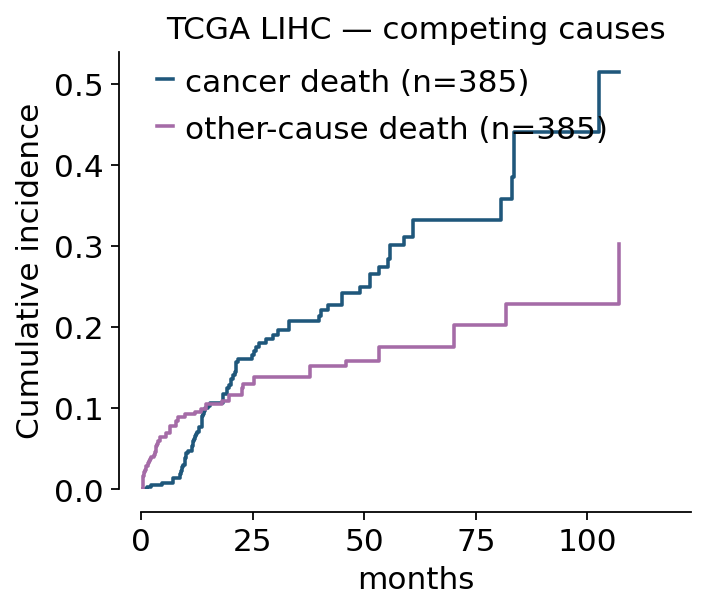

In [15]:
ax = ov.pl.cumulative_incidence(lihc, "months", "cause", cause=[1, 2],
                                cause_labels={1: "cancer death",
                                              2: "other-cause death"},
                                figsize=(4.4, 3.6), test=False,
                                title="TCGA LIHC — competing causes")
plt.show()

## 4. Forest plots — `ov.pl.forest`

Now the same stage comparison across every cancer type with enough events. For
each type we take the log-rank hazard ratio and its standard error, then pool
them. This is exactly the shape a forest plot exists for.

In [16]:
stages = ["Stage III-IV", "Stage I-II"]
rows = []
for name, part in cohort.groupby("cancer type abbreviation", observed=True):
    counts = part.groupby("stage", observed=False)["OS"].sum()
    if counts.reindex(stages).min() < 15:
        continue
    res = ov.pl.logrank_test(part["months"], part["OS"], part["stage"],
                             groups=stages)
    rows.append({"cancer": name, "HR": res["hazard_ratio"],
                 "se": np.sqrt(1 / res["expected"][0] + 1 / res["expected"][1]),
                 "P": res["pvalue"], "n": len(part)})
hr = pd.DataFrame(rows).sort_values("HR")
hr.head()

,cancer,HR,se,P,n
10,MESO,0.993131,0.255424,0.977417,85
4,HNSC,1.585311,0.147830,0.005438,527
11,SKCM,1.659092,0.148302,0.000226,424
9,LUSC,1.690619,0.165445,0.000152,611
7,LIHC,2.099226,0.193818,0.000005,398


`log_scale=True` puts the ratios on a log axis with the null at 1, which
is the only honest way to draw a ratio: it makes HR = 0.5 and HR = 2 the same
distance from the line. `meta='random'` adds the DerSimonian-Laird pooled
estimate as a diamond, with Q, I² and tau² underneath.

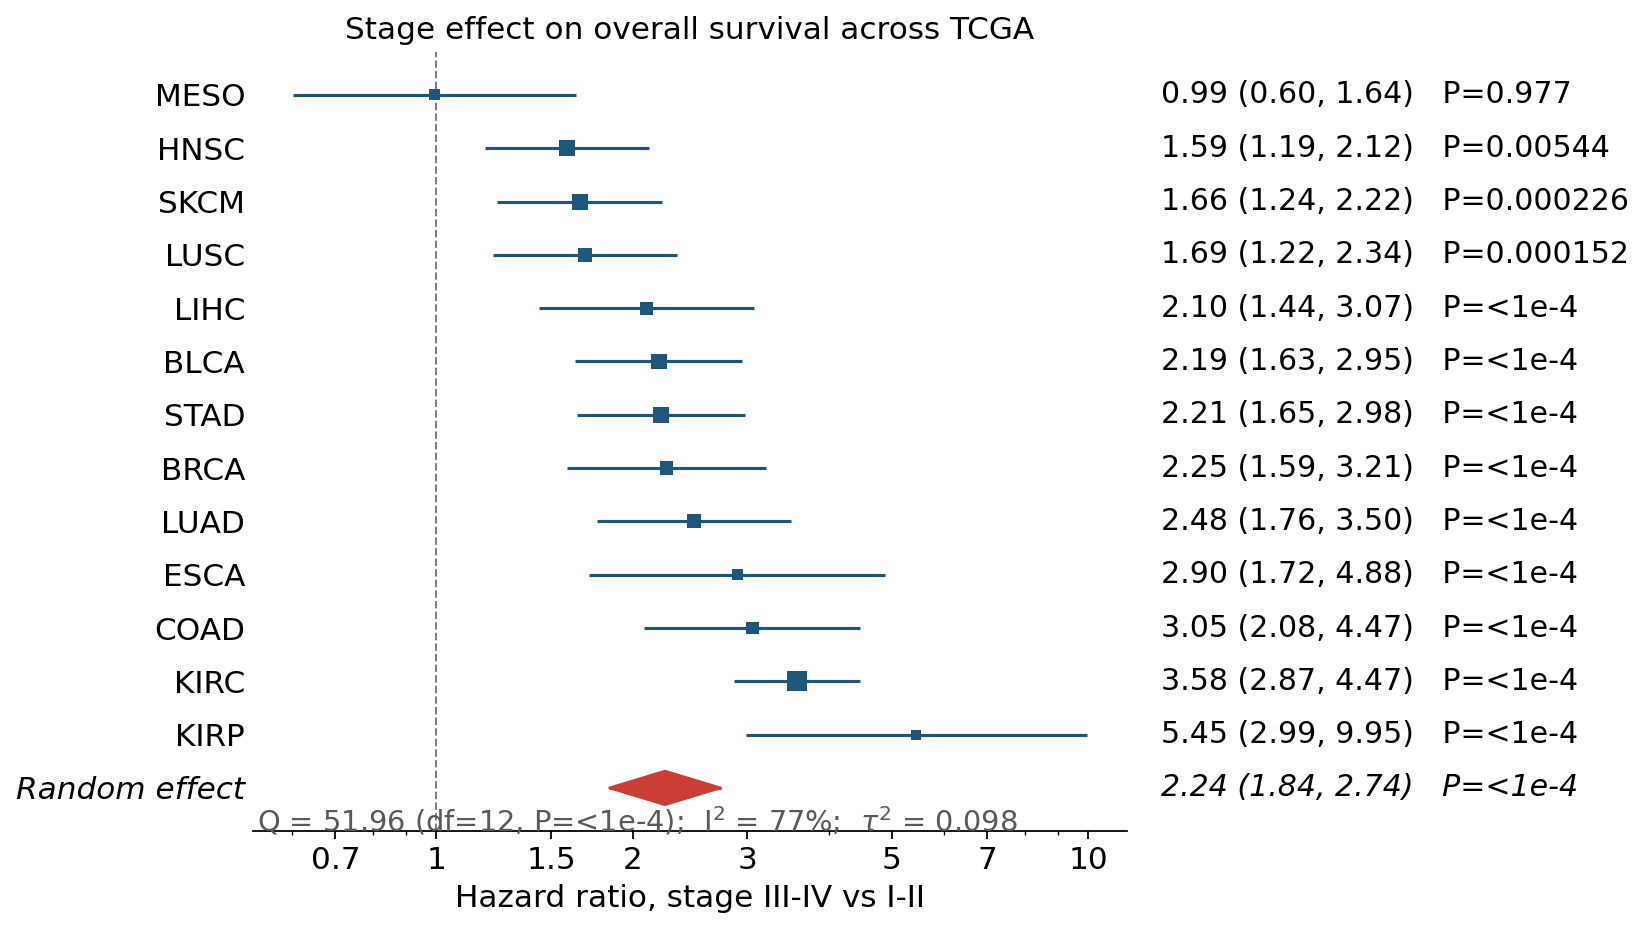

In [17]:
ax = ov.pl.forest(hr, "HR", se="se", label="cancer", pvalue="P",
                  log_scale=True, meta="random", figsize=(7.0, 6.4),
                  xlabel="Hazard ratio, stage III-IV vs I-II",
                  title="Stage effect on overall survival across TCGA")
plt.show()

In [18]:
ax, meta = ov.pl.forest(hr, "HR", se="se", label="cancer", log_scale=True,
                        meta="both", figsize=(6.4, 6.0), return_stats=True)
plt.close()
pooled = meta["meta"]["random"]
print(f"pooled HR = {np.exp(pooled['estimate']):.2f} "
      f"({np.exp(pooled['lower']):.2f}-{np.exp(pooled['upper']):.2f})")
print(f"heterogeneity: I2 = {100 * pooled['I2']:.0f}%, tau2 = {pooled['tau2']:.3f}, Q P = {pooled['Q_pvalue']:.1e}")

pooled HR = 2.24 (1.84-2.74)
heterogeneity: I2 = 77%, tau2 = 0.098, Q P = 6.3e-07


Subgroups get bold headers and keep their block together — useful when
the rows fall into families (organ system, platform, study site).

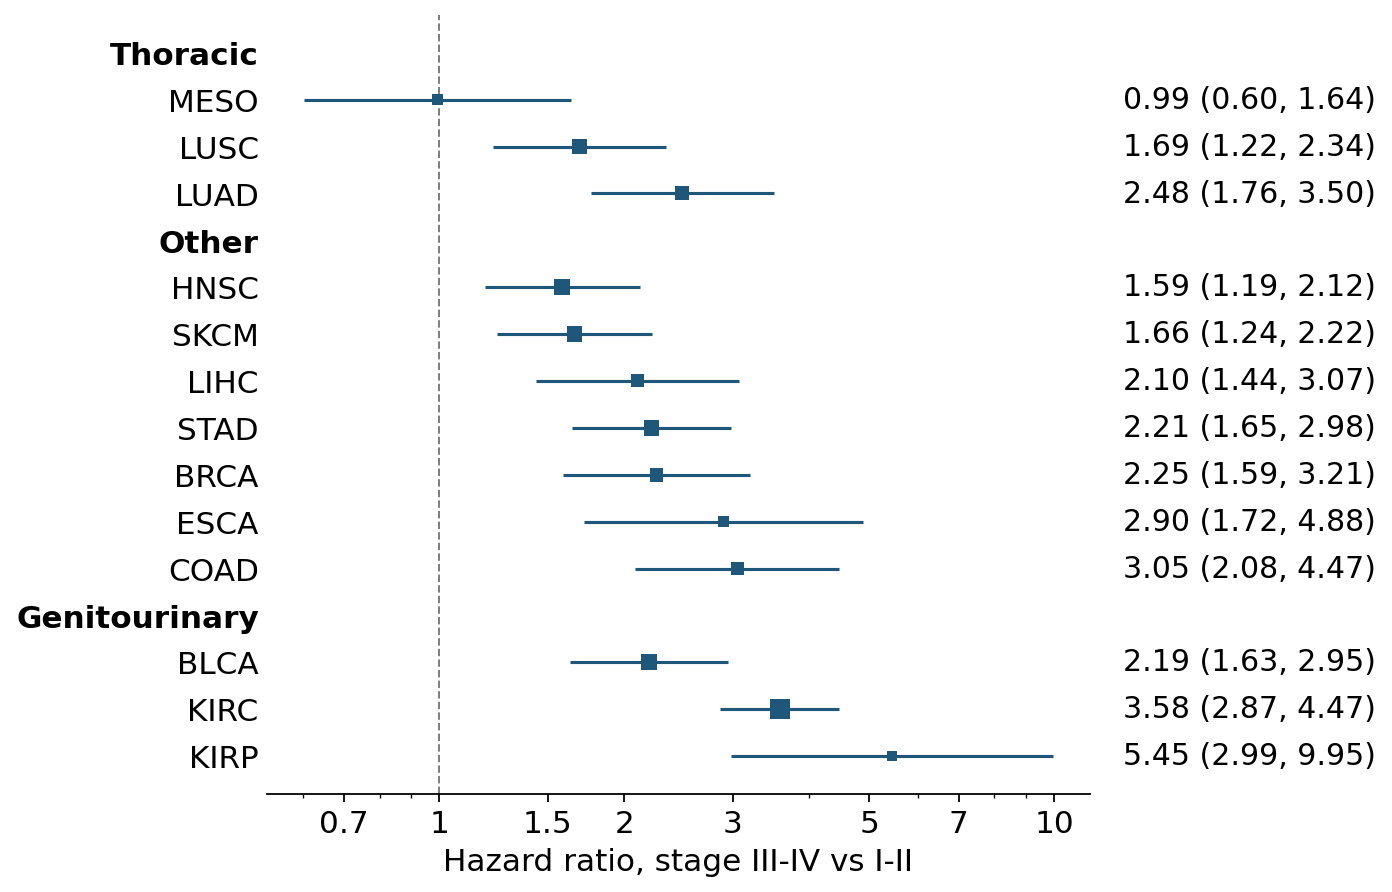

In [19]:
hr["organ"] = np.where(hr["cancer"].isin(["LUAD", "LUSC", "MESO"]), "Thoracic",
                np.where(hr["cancer"].isin(["KIRC", "KIRP", "BLCA", "PRAD"]), "Genitourinary",
                         "Other"))
ax = ov.pl.forest(hr, "HR", se="se", label="cancer", group="organ",
                  log_scale=True, figsize=(6.6, 6.4),
                  xlabel="Hazard ratio, stage III-IV vs I-II")
plt.show()

## 5. ROC curves — `ov.pl.roc`

A different question: can we predict three-year mortality from what is known at
diagnosis? We keep the patients whose outcome at three years is unambiguous —
either they died within three years, or they were followed for at least three
years — and fit two models on age, stage, sex and cancer type.

In [20]:
model_df = both.dropna(subset=["age_at_initial_pathologic_diagnosis", "stage", "gender"]).copy()
resolved = (model_df["months"] >= 36) | (model_df["OS"] == 1)
model_df = model_df[resolved]
model_df["died_3y"] = ((model_df["OS"] == 1) & (model_df["months"] < 36)).astype(int)
print(f"{len(model_df)} patients, {model_df['died_3y'].mean():.1%} died within 3 years")

4373 patients, 38.2% died within 3 years


In [21]:
features = pd.get_dummies(
    model_df[["age_at_initial_pathologic_diagnosis", "stage", "gender",
              "cancer type abbreviation"]],
    columns=["stage", "gender", "cancer type abbreviation"], drop_first=True,
).astype(float)
target = model_df["died_3y"].to_numpy()
features.shape

(4373, 23)

In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_tr, X_te, y_tr, y_te = train_test_split(features.to_numpy(), target,
                                          test_size=0.3, random_state=0,
                                          stratify=target)

In [23]:
scaler = StandardScaler().fit(X_tr)
logit = LogisticRegression(max_iter=2000).fit(scaler.transform(X_tr), y_tr)
boost = GradientBoostingClassifier(random_state=0).fit(X_tr, y_tr)
age_only = LogisticRegression(max_iter=2000).fit(X_tr[:, :1], y_tr)

The legend carries the AUC and its **DeLong** 95% interval — the analytic
interval that R's `pROC` computes, not a bootstrap approximation.

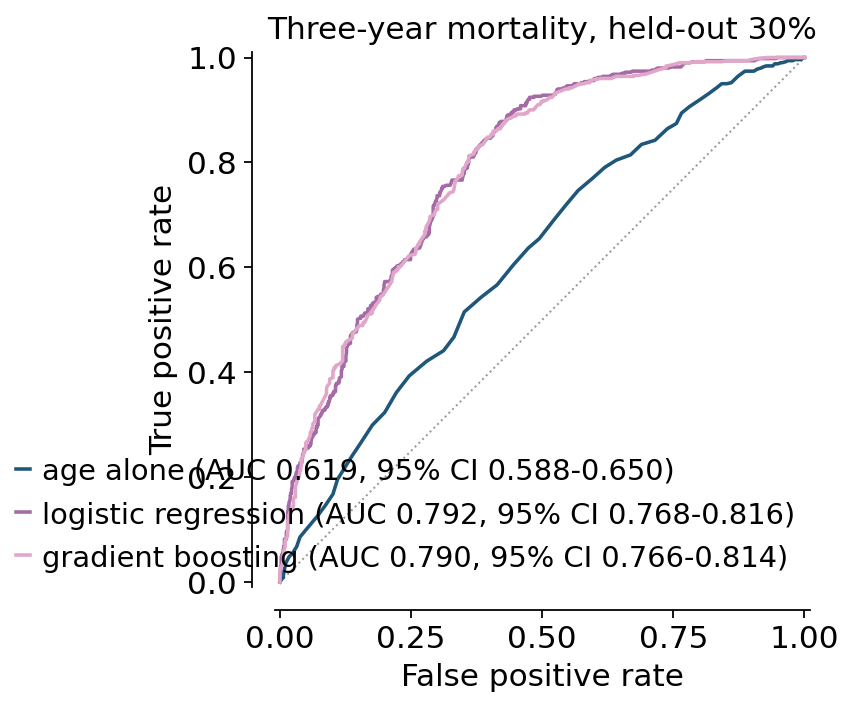

In [24]:
scores = {"age alone": age_only.predict_proba(X_te[:, :1])[:, 1],
          "logistic regression": logit.predict_proba(scaler.transform(X_te))[:, 1],
          "gradient boosting": boost.predict_proba(X_te)[:, 1]}
ax = ov.pl.roc(y_true=y_te, y_score=scores, figsize=(4.4, 4.4),
               title="Three-year mortality, held-out 30%")
plt.show()

`ci='bootstrap'` additionally shades the curve itself, which shows where
the model is actually resolved and where a handful of patients are carrying the
shape.

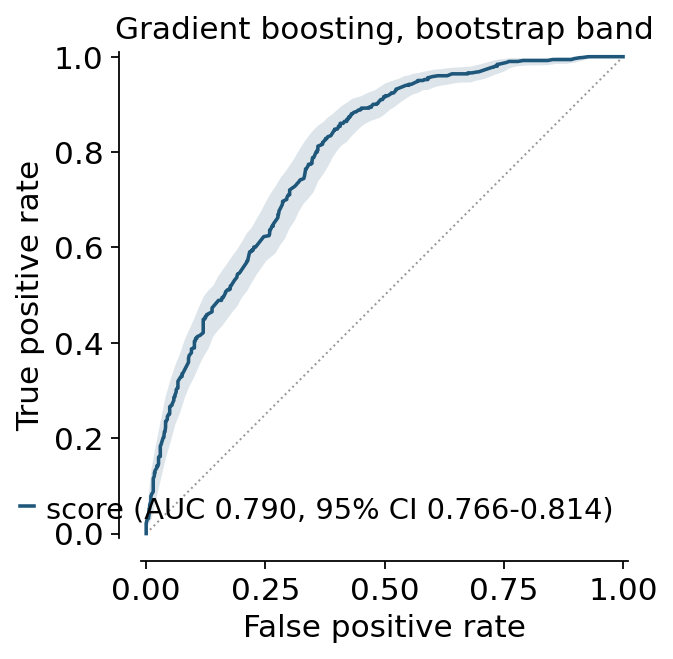

In [25]:
ax, roc_stats = ov.pl.roc(y_te, scores["gradient boosting"],
                          ci="bootstrap", n_boot=400, figsize=(4.0, 4.0),
                          title="Gradient boosting, bootstrap band",
                          return_stats=True)
plt.show()

In [26]:
curve = roc_stats["curves"]["score"]
print(f"AUC = {curve['auc']:.3f} (95% CI {curve['lower']:.3f}-{curve['upper']:.3f}), SE = {curve['se']:.4f}")

AUC = 0.790 (95% CI 0.766-0.814), SE = 0.0123


For a multi-class problem pass the probability matrix and the class
names: one one-vs-rest curve per class, plus the macro and micro averages.

In [27]:
top = model_df["cancer type abbreviation"].value_counts().head(4).index.tolist()
subset = model_df[model_df["cancer type abbreviation"].isin(top)]
Xc = pd.get_dummies(subset[["age_at_initial_pathologic_diagnosis", "stage",
                            "gender"]], drop_first=True).astype(float)
yc = subset["cancer type abbreviation"].to_numpy()
multi = LogisticRegression(max_iter=3000).fit(Xc.to_numpy(), yc)

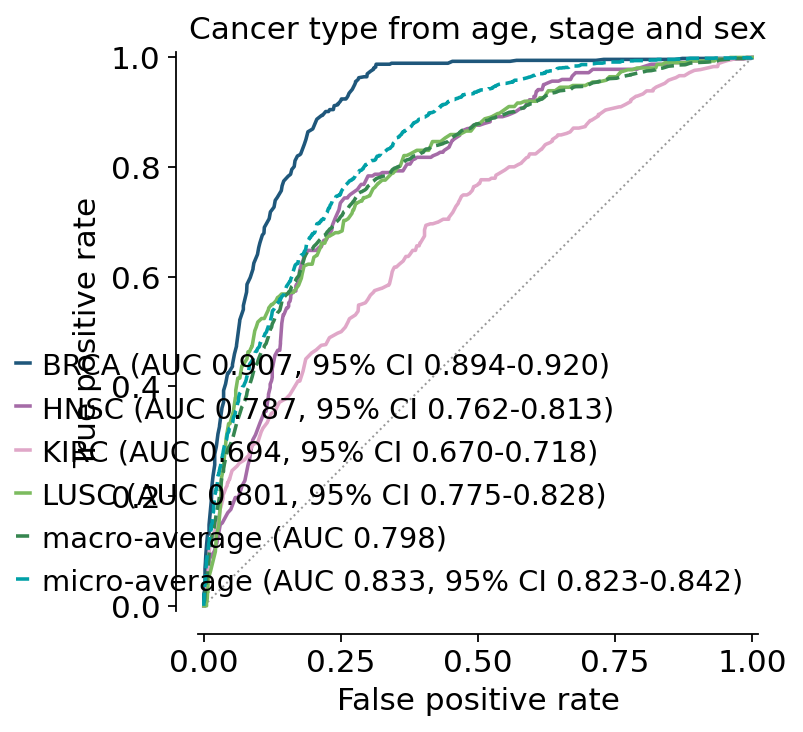

In [28]:
ax = ov.pl.roc(y_true=yc, y_score=multi.predict_proba(Xc.to_numpy()),
               score_names=multi.classes_, average="both", figsize=(4.6, 4.6),
               title="Cancer type from age, stage and sex")
plt.show()

## 6. Confusion matrices — `ov.pl.confusion`

`normalize='true'` divides by the row total, so each cell is a recall and the
classes are comparable even though they are wildly imbalanced. `metrics=True`
adds the per-class precision / recall / F1 strip; the title carries accuracy,
balanced accuracy and Cohen's kappa.

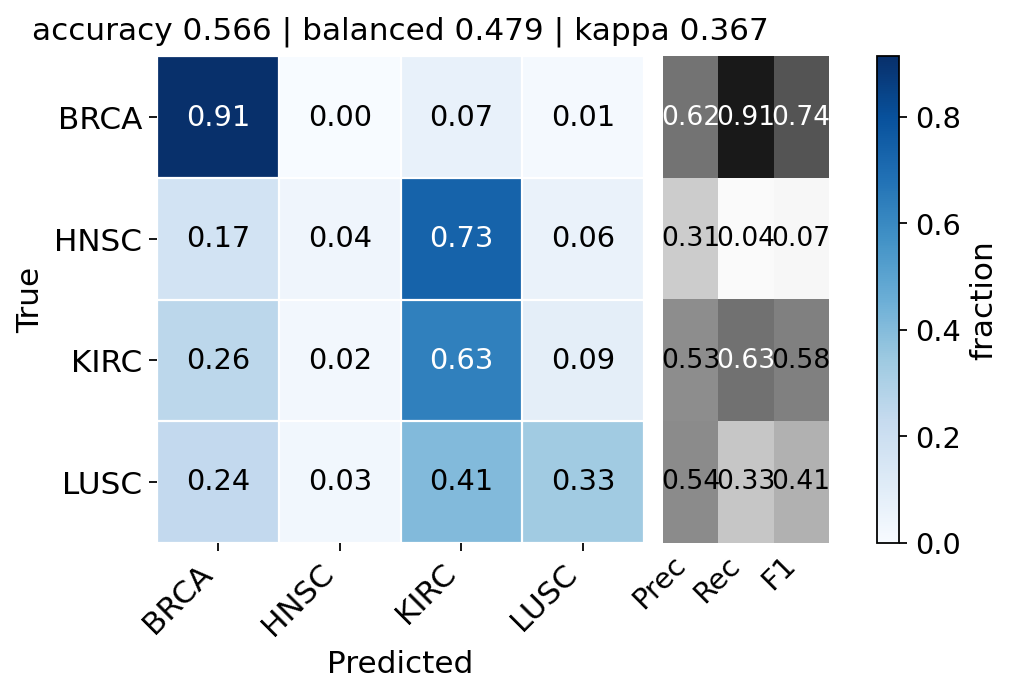

In [29]:
ax, cm = ov.pl.confusion(y_true=yc, y_pred=multi.predict(Xc.to_numpy()),
                         normalize="true", metrics=True, figsize=(6.4, 4.0),
                         return_stats=True)
plt.show()

In [30]:
cm["per_class"].round(3)

,precision,recall,f1,support
BRCA,0.623,0.914,0.741,568
HNSC,0.308,0.037,0.066,324
KIRC,0.530,0.632,0.576,722
LUSC,0.536,0.332,0.410,313


With `counts_and_percent=True` each cell shows the raw count above the
row percentage, which is what a supplementary table usually needs.

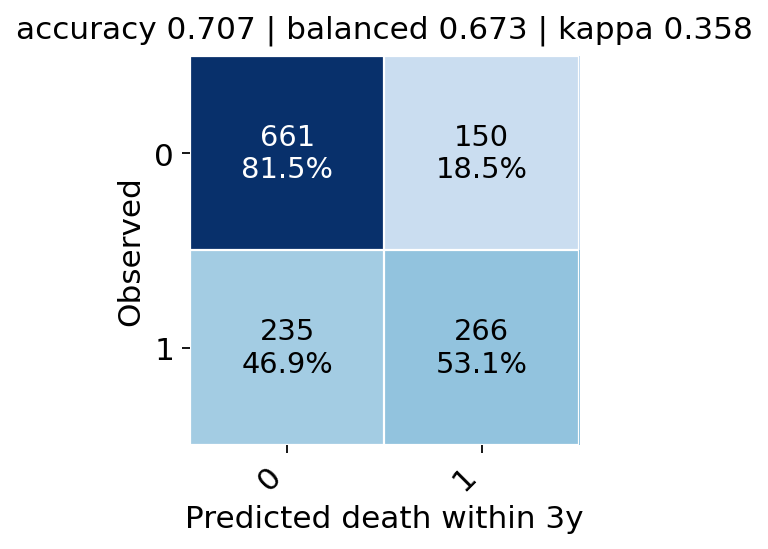

In [31]:
ax = ov.pl.confusion(y_true=y_te, y_pred=(scores["gradient boosting"] > 0.5).astype(int),
                     labels=[0, 1], counts_and_percent=True, colorbar=False,
                     figsize=(3.4, 3.2), xlabel="Predicted death within 3y",
                     ylabel="Observed")
plt.show()

## 7. Figure geometry — `ov.pl.figure` and `ov.pl.multipanel`

Journals specify width in millimetres. `matplotlib` speaks inches. `ov.pl.figure`
takes mm, cm, inches or pixels — and the column widths of the common journals by
name, so `figure('nature-single', 60)` is exactly 89 mm wide.

In [32]:
fig = ov.pl.figure("nature-single", 60)
print("inches:", fig.get_size_inches())
print("mm    :", fig.get_size_inches() * 25.4)
plt.close(fig)
{k: ov.pl.JOURNAL_WIDTH_MM[k] for k in
 ["nature-single", "nature-double", "science-single", "cell-double"]}

inches: [3.50393701 2.36220472]
mm    : [89. 60.]


{'nature-single': 89.0,
 'nature-double': 183.0,
 'science-single': 55.0,
 'cell-double': 174.0}

In [33]:
fig = ov.pl.figure(1200, 800, units="px", dpi=150)
print("pixels:", fig.get_size_inches() * fig.dpi)
plt.close(fig)

pixels: [1200.  800.]


`ov.pl.multipanel` builds the grid, tags the panels in reading order and
returns the axes in a dict keyed by the tag — so a panel is referred to by the
letter that appears on it. A mosaic string works too, where repeated letters
span cells and `.` leaves a gap.

Here is a complete Figure 1 assembled from the analyses above, at Nature
double-column width.

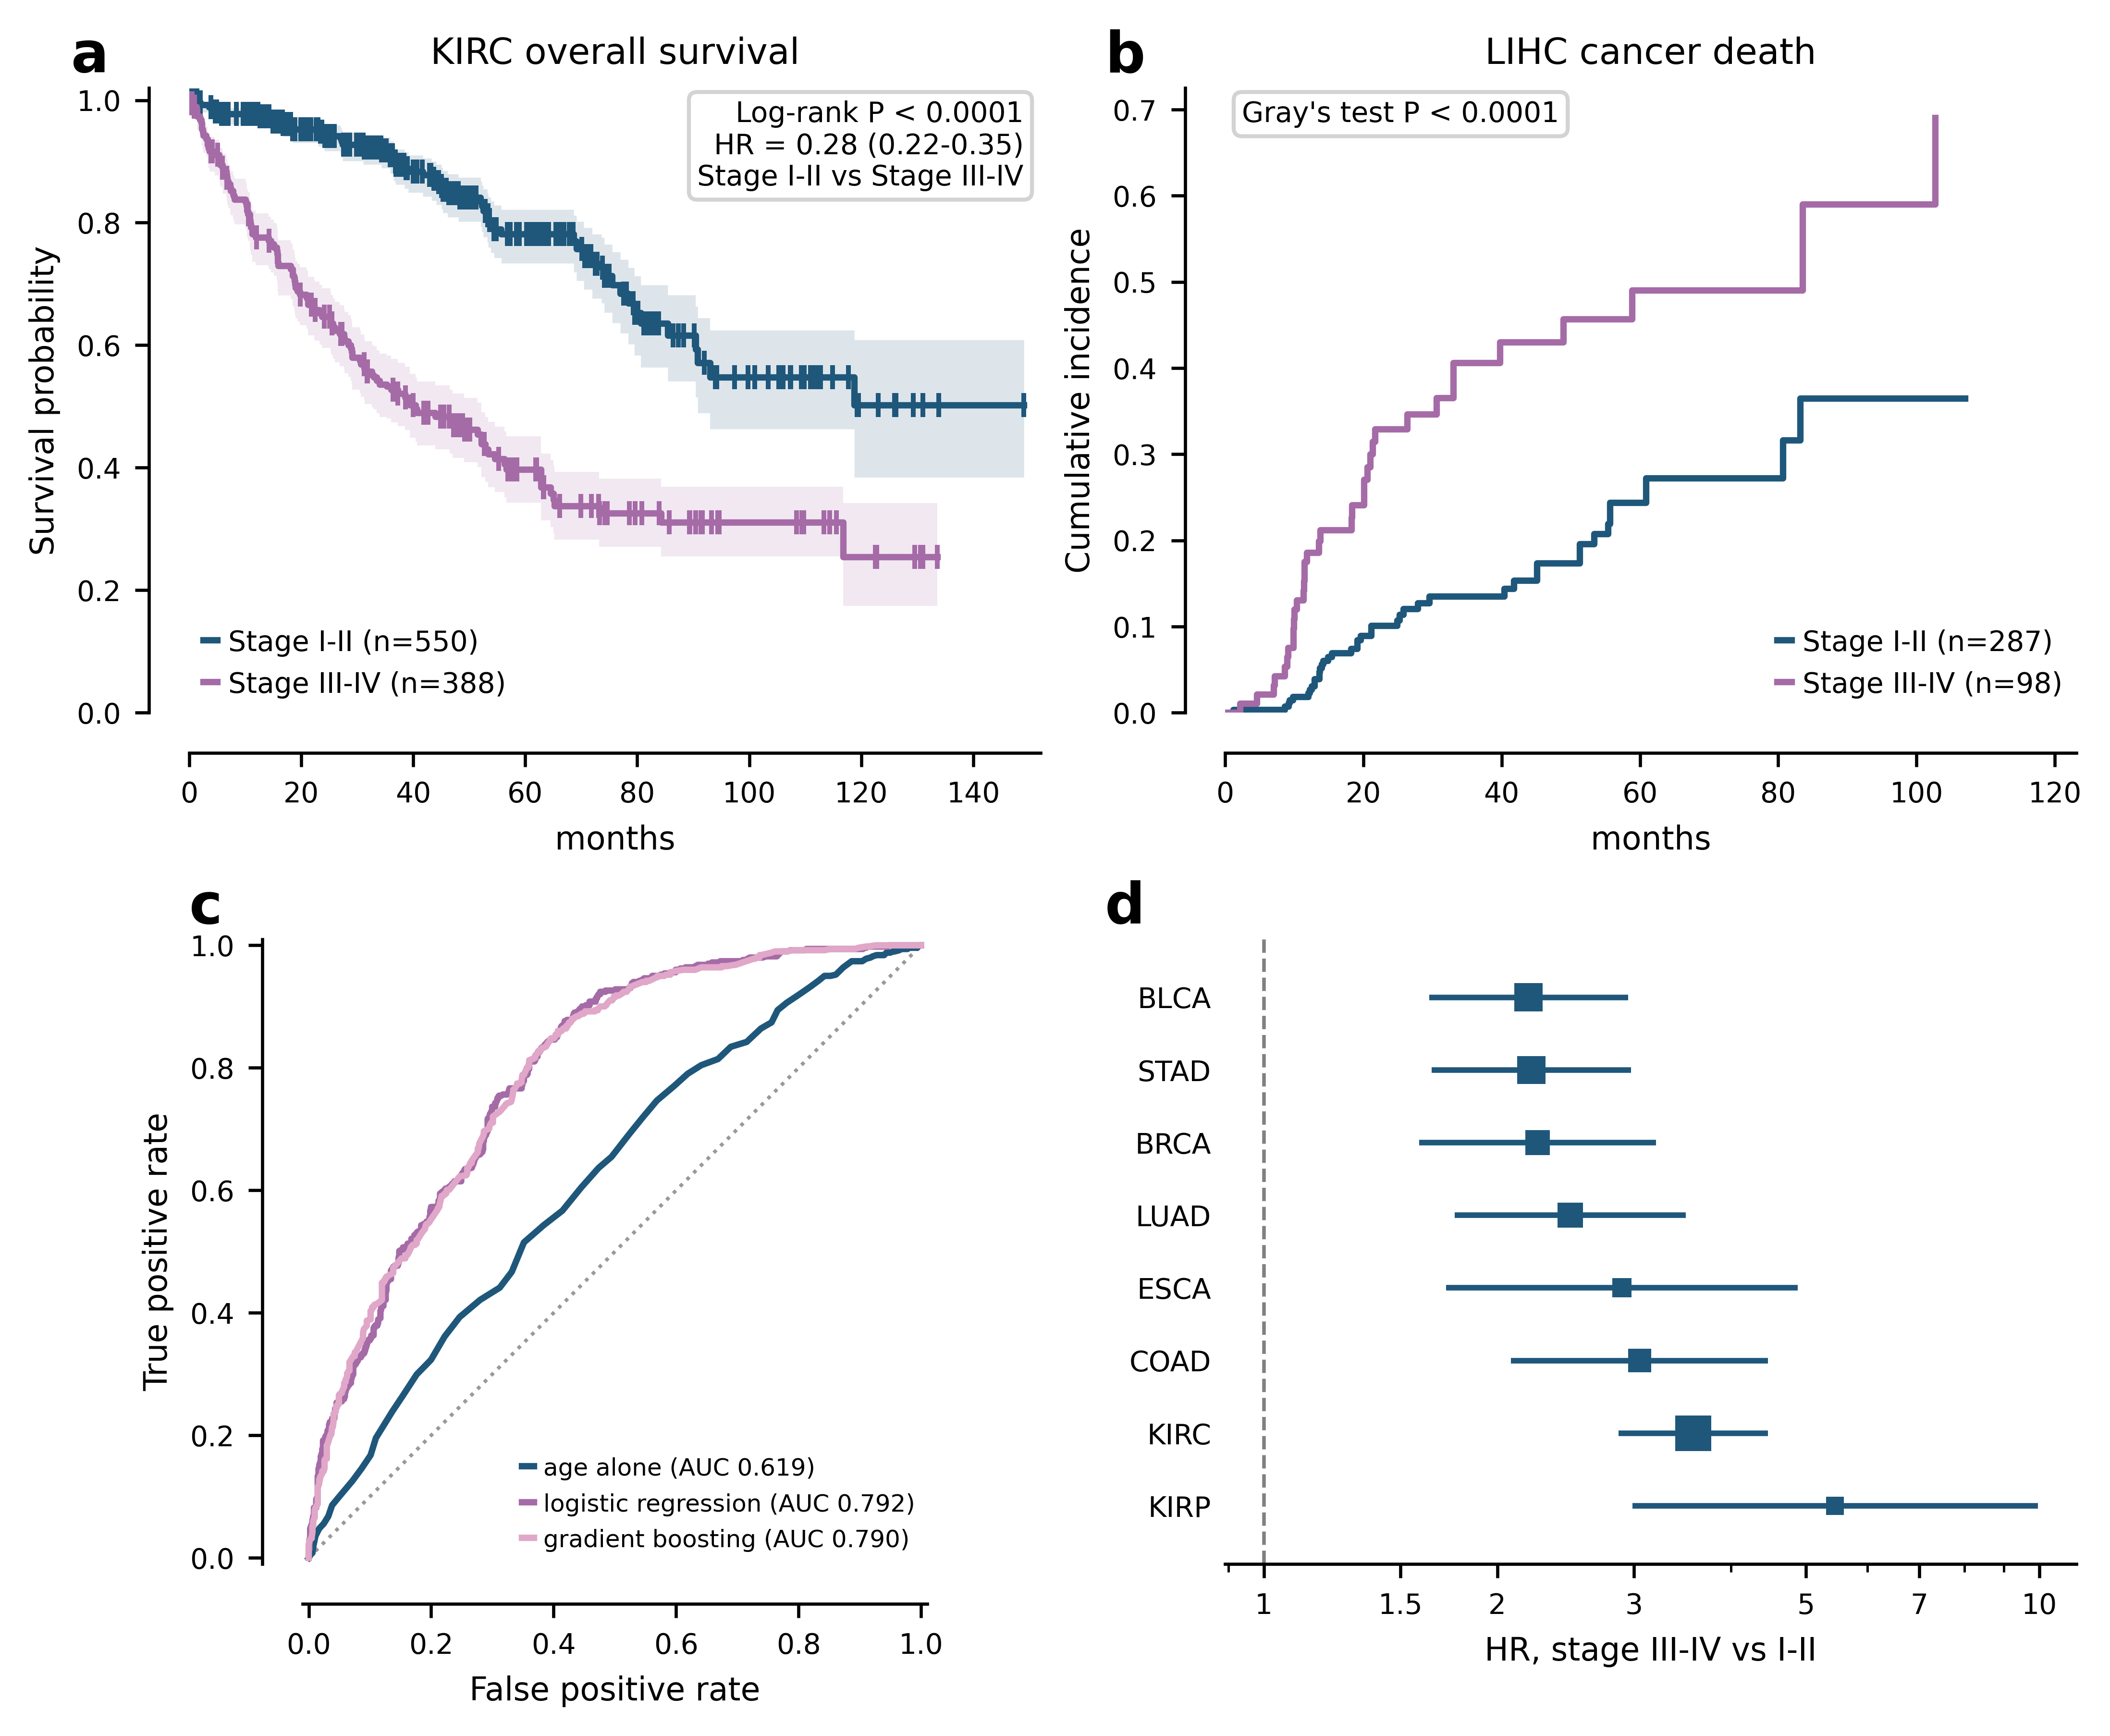

In [34]:
fig, axes = ov.pl.multipanel("AB\nCD", width="nature-double", height=150,
                             label="a")
ov.pl.survival(kirc, "months", "OS", "stage", ax=axes["A"], risk_table=False,
               fontsize=7, title="KIRC overall survival")
ov.pl.cumulative_incidence(lihc, "months", "cause", "stage", cause=1,
                           ax=axes["B"], fontsize=7, title="LIHC cancer death")
ov.pl.roc(y_true=y_te, y_score=scores, ax=axes["C"], fontsize=7, ci=None)
ov.pl.forest(hr.tail(8), "HR", se="se", label="cancer", log_scale=True,
             ax=axes["D"], fontsize=7, annotate=False,
             xlabel="HR, stage III-IV vs I-II")
plt.show()

`ov.pl.add_panel_label` places a tag by itself, offset from the axes
corner in **points** rather than axes fractions — so the same offset looks the
same on a 40 mm and a 180 mm panel. `ov.pl.take_legend_out` moves a legend
clear of the data.

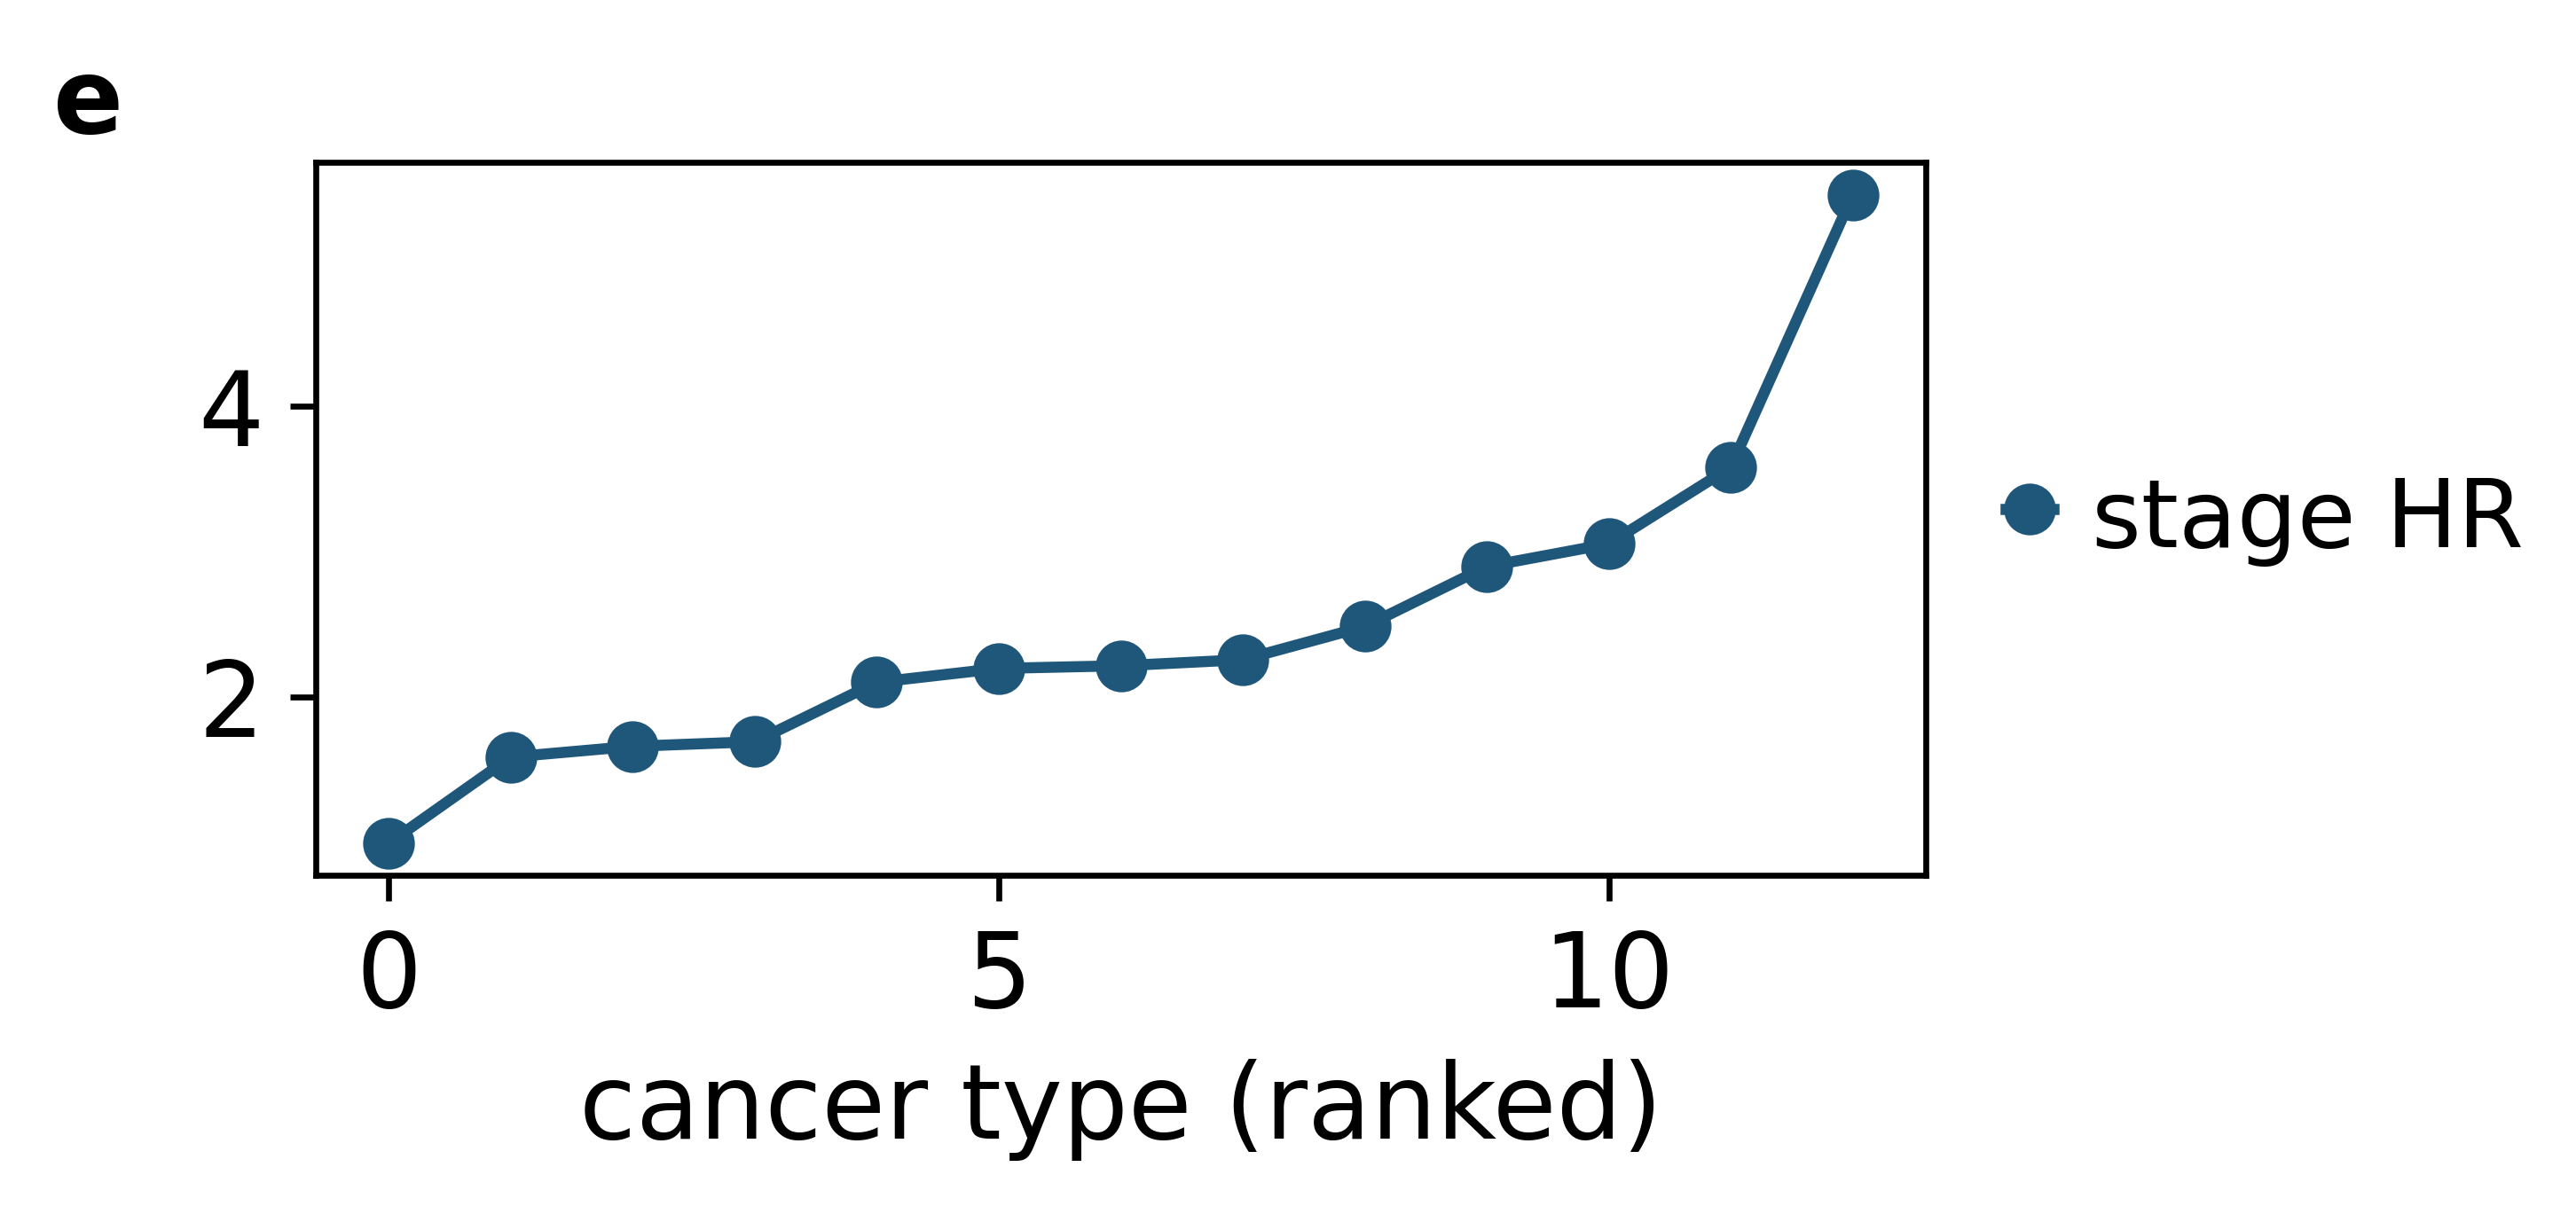

In [35]:
fig, ax = ov.pl.figure(120, 55, axes=True)
ax.plot(hr["HR"].to_numpy(), "o-", label="stage HR")
ax.set_xlabel("cancer type (ranked)")
ov.pl.add_panel_label(ax, "e", dx=-26, dy=4)
ov.pl.take_legend_out(ax, loc="right")
plt.show()

## 8. Export — `ov.pl.savefig`

Two defaults matter here. `svg.fonttype='none'` stops matplotlib converting
every glyph into a path, so the labels in the SVG are still text you can select
and retype in Illustrator or Inkscape. `pdf.fonttype=42` embeds TrueType rather
than Type-3 fonts, which is what makes a PDF editable at all.

One call writes every format you need.

In [36]:
paths = ov.pl.savefig(fig, "figures/figure1", formats=["pdf", "svg", "png"],
                      dpi=600)
[os.path.basename(p) for p in paths]

Saved: figures/figure1.pdf, figures/figure1.svg, figures/figure1.png


['figure1.pdf', 'figure1.svg', 'figure1.png']

In [37]:
svg = open("figures/figure1.svg").read()
print("SVG contains <text> nodes :", "<text" in svg)
print("label is still a string   :", "cancer type (ranked)" in svg)

SVG contains <text> nodes : True
label is still a string   : True


If you prefer to keep using `plt.savefig` directly, flip the same
defaults globally once:

```python
ov.pl.set_editable_text()      # every later savefig keeps text as text
```

One caveat, and it is the price of editability: `svg.fonttype='none'` means the
SVG *references* the font by name instead of embedding outlines. Whoever opens
the file needs that font installed, or their viewer substitutes one. For a
camera-ready file that nobody will edit again, `ov.pl.set_editable_text(False)`
goes back to outlined glyphs, which always render identically.

Pass `bbox_inches=None` when a journal asks for a figure of an exact width —
the default `'tight'` crops to the drawn content and will shave a millimetre or
two off the canvas you asked `ov.pl.figure` for.

## 9. Not tied to AnnData

Everything above took a `DataFrame`. The same calls accept bare arrays, or an
`AnnData` — in which case `.obs` is read. All three give the same numbers.

In [38]:
import anndata

adata = anndata.AnnData(np.zeros((len(kirc), 1), dtype=np.float32),
                        obs=kirc.reset_index(drop=True))
_, from_adata = ov.pl.survival(adata, "months", "OS", "stage", return_stats=True)
_, from_frame = ov.pl.survival(kirc, "months", "OS", "stage", return_stats=True)
plt.close("all")

In [39]:
_, from_arrays = ov.pl.survival(time=kirc["months"].to_numpy(),
                                event=kirc["OS"].to_numpy(),
                                group=kirc["stage"].astype(str).to_numpy(),
                                return_stats=True)
plt.close("all")
for label, s in [("DataFrame", from_frame), ("arrays", from_arrays),
                 ("AnnData", from_adata)]:
    print(f"{label:<10} log-rank chi2 = {s['statistic']:.6f}, "
          f"HR = {s['hazard_ratio']:.6f}")

DataFrame  log-rank chi2 = 140.016106, HR = 0.279415
arrays     log-rank chi2 = 140.016106, HR = 0.279415
AnnData    log-rank chi2 = 140.016106, HR = 0.279415


## 10. The statistics without the picture

Every figure above is drawn from a number that is available on its own. When
what you need is the value for a table or a sentence, call the estimator
directly — each returns a plain dict, so nothing has to be scraped back off an
axes.

In [40]:
fit = ov.pl.kaplan_meier(kirc["months"], kirc["OS"])
lo, hi = fit["median_ci"]
print(f"median OS {fit['median']:.1f} months (95% CI {lo:.1f}-{hi:.1f}), "
      f"{fit['n_events']}/{fit['n']} events")

median OS 84.2 months (95% CI 74.1-93.0), 338/938 events


In [41]:
lr = ov.pl.logrank_test(kirc["months"], kirc["OS"], kirc["stage"],
                        groups=["Stage III-IV", "Stage I-II"])
print(f"log-rank chi2 = {lr['statistic']:.1f}, {ov.pl.format_pvalue(lr['pvalue'], 'value')}")
print("stars:", ov.pl.format_pvalue(lr["pvalue"]))

log-rank chi2 = 140.0, P = 2.6e-32
stars: ****


`ov.pl.grays_test` is the competing-risk counterpart, and it answers a
different question from a log-rank on the same data — the log-rank compares
cause-specific hazards, Gray's compares the incidence curves you actually
plotted. On this cohort they agree; when the competing risk differs between
groups they need not.

In [42]:
gray = ov.pl.grays_test(lihc["months"], lihc["cause"], lihc["stage"], cause=1)
naive = ov.pl.logrank_test(lihc["months"], lihc["cause"] == 1, lihc["stage"])
print(f"Gray's test          chi2 = {gray['statistic']:6.2f}  P = {gray['pvalue']:.2e}")
print(f"cause-specific LR    chi2 = {naive['statistic']:6.2f}  P = {naive['pvalue']:.2e}")

Gray's test          chi2 =  24.18  P = 8.75e-07
cause-specific LR    chi2 =  28.45  P = 9.61e-08


In [43]:
auc = ov.pl.roc_auc_ci(y_te, scores["gradient boosting"])
print(f"AUC {auc['auc']:.3f} (DeLong 95% CI {auc['lower']:.3f}-{auc['upper']:.3f}), "
      f"SE {auc['se']:.4f}")

AUC 0.790 (DeLong 95% CI 0.766-0.814), SE 0.0123


In [44]:
pooled = ov.pl.meta_analysis(np.log(hr["HR"]), hr["se"], method="random")
print(f"pooled HR {np.exp(pooled['estimate']):.2f} "
      f"({np.exp(pooled['lower']):.2f}-{np.exp(pooled['upper']):.2f})")
print(f"Q = {pooled['Q']:.1f} (df {pooled['df']}), I2 = {100 * pooled['I2']:.0f}%, "
      f"tau2 = {pooled['tau2']:.3f}")

pooled HR 2.24 (1.84-2.74)
Q = 52.0 (df 12), I2 = 77%, tau2 = 0.098


And the export defaults can be set globally, for code that calls
`plt.savefig` directly rather than going through `ov.pl.savefig`.

In [45]:
previous = ov.pl.set_editable_text(True)
print({k: plt.rcParams[k] for k in ("svg.fonttype", "pdf.fonttype", "ps.fonttype")})
print("previous values:", previous)

{'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42}
previous values: {'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42}


## Summary

| Task | Call |
| --- | --- |
| Survival by group, with everything a reviewer asks for | `ov.pl.survival(df, 'time', 'event', 'group')` |
| Incidence when patients can die of something else | `ov.pl.cumulative_incidence(df, 'time', 'cause', 'group', cause=1)` |
| Compare classifiers | `ov.pl.roc(y_true=y, y_score={'A': a, 'B': b})` |
| Where a classifier confuses classes | `ov.pl.confusion(y_true=y, y_pred=p, normalize='true')` |
| Effect sizes across cohorts, pooled | `ov.pl.forest(df, 'HR', se='se', log_scale=True, meta='random')` |
| A canvas at a journal's column width | `ov.pl.figure('nature-double', 150)` |
| A labelled panel figure | `ov.pl.multipanel('AB\nCD', width='nature-double', height=150)` |
| Export with editable text | `ov.pl.savefig(fig, 'figure1', formats=['pdf', 'svg'])` |

The estimators are also available on their own, without drawing anything:
`ov.pl.kaplan_meier`, `ov.pl.logrank_test`, `ov.pl.aalen_johansen`,
`ov.pl.grays_test`, `ov.pl.roc_auc_ci` and `ov.pl.meta_analysis` all return
plain dictionaries.